# Companies really do cook earnings without touching the books. Can you trade it? 🎭
### 'Real earnings management' — overproduce and slash R&D to hit the number — is a genuine forensic tell. As a stock signal it's a coin-flip.

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Operating reversal%3F: Not detected](https://img.shields.io/badge/Operating_reversal%3F-Not_detected-8b949e?style=flat-square)

When a company is about to *miss* the number Wall Street expects, it has two ways to fudge it. The famous one is **accrual** management — accounting choices about when to book things. The sneakier one, and the subject here, is **real** earnings management (Roychowdhury 2006): change the *actual business* for a quarter. **Overproduce** — run the factory hot so fixed costs spread over more units and the reported cost of each sale drops. **Cut discretionary spend** — freeze R&D, trim SG&A, kill the ad budget. Both flatter this quarter's profit, and both leave a fingerprint: production looks *abnormally high*, discretionary expense *abnormally low*.

The forensic idea is real and well-documented. The tempting leap — *so buy the manipulators, or short them* — is where it falls apart.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 44 large US manufacturers / hardware / pharma / industrials that disclose the needed line items on EDGAR (32 usable), 2009→2026; a genuinely **thin, uneven panel**. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from real_earn_mgmt import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 32, 'n_roster': 44, 'n_events': 630, 'end_lo': '2009-07-31', 'end_hi': '2026-03-31', 'fp_prices': 'e443c0a5d730', 'n_months': 153, 'avg_n': 17.1, 'ls_span_lo': '2009-11-30', 'ls_span_hi': '2026-03-31', 'ls_mean_bps': -9.2, 'ls_ann': -1.1, 'ls_t_iid': -0.21, 'ls_t_nw': -0.16, 'ls_sharpe': -0.06, 'ls_hit': 46, 'ls_long_bps': 179.6, 'ls_short_bps': 188.8, 'ls_turn': 0.16, 'ls120_mean_bps': 75.3, 'ls120_t_nw': 1.82, 'abprod_mean_bps': -5.5, 'abprod_t_nw': -0.09, 'abdisx_mean_bps': 30.7, 'abdisx_t_nw': 0.69, 'drift': {21: (630, 1.7, 1.26, 0.44, 0.63, 46, 0.5308), 63: (629, 4.65, 5.52, -0.87, -0.62, 47, 0.4903), 126: (628, 10.16, 10.45, -0.28, -0.14, 45, 0.8796)}, 'mono63': (5.52, 3.39, 4.65), 'era_early_n': 62, 'era_early_bps': 69.5, 'era_early_t': 1.02, 'era_late_n': 91, 'era_late_bps': -62.8, 'era_late_t': -0.79, 'op_n': 339, 'op_slope': 0.0569, 'op_t': 1.36, 'op_r2': 0.005, 'op_corr': 0.074, 'op_top_dgm': 0.56, 'op_bot_dgm': 0.08, 'op_spread': 0.48, 'net': {(10, 50): (-9.0, -1.08, -0.16, -0.06), (20, 100): (-8.8, -1.05, -0.16, -0.06)}, 'syn_null_mean': 0.31, 'syn_null_sd': 0.78, 'syn_null_fire': 0, 'syn_null_seeds': 12, 'syn_planted_bps': 874.2, 'syn_planted_t': 20.28}


real cache present: True | events: 630 | names: 32


## The answer first

| Question | Answer |
|---|---|
| Is 'real earnings management' a real thing? | **Yes.** Firms demonstrably overproduce and cut discretionary spend to hit targets — it's one of the most-cited results in accounting. |
| Does the fingerprint predict **stock returns**? | **No.** A long-short that ranks firms on the real-management proxy earns **-9 bps/month** — a robust *t* of **-0.16**, an unmistakable zero. |
| Is it at least *stably* zero? | **Not even that.** Nudge one knob (how stale a signal you'll hold) and the sign flips from −9 to **+75 bps/mo**; cut the sample at 2015 and it's **+70 bps early, −63 late**. A real edge doesn't flip sign when you sneeze on it. |
| Can you trade it? | **No.** There is nothing to charge costs against. |

> A great forensic tell about the *business* is not automatically a signal about the *stock*. That distinction is the whole study.

## 1 · The claim

> *"Firms about to miss earnings overproduce (to bury fixed costs in inventory) and cut R&D / SG&A. That leaves abnormally high production and abnormally low discretionary expense — spot it, and you've spotted a manipulator whose stock will eventually pay for it."*

Roychowdhury (2006) built exactly this: fit a 'normal' level of production and of discretionary expense from ordinary firms, and call the leftover — the **residual** — the *abnormal*, real-management piece. The follow-up literature argues real management is **value-destroying** (you discount the excess inventory later; you starve the R&D that drives growth), so the manipulators should *under*-perform. We test whether that shows up in tradeable returns.

## 2 · So what?

If a residual you can compute from any 10-Q flagged tomorrow's losers, it would be a gift: no insider data, just cost of goods sold and R&D. That is precisely why to be suspicious. Everyone can read the same filing; if the market prices public forensic signals at all, this is the kind it should price fast — and a 'signal' that only *sometimes* has a sign is usually noise wearing a lab coat.

## 3 · How would we even know?

- **The signal.** For each of 32 manufacturers we fit Roychowdhury's two 'normal' models and take the residuals: **abnormal production** (high = overproducing) and **abnormal discretionary expense** (low = cutting). Add them into one **REM** score, known only on the **filing date** (no peeking).
- **The return test.** Each month, rank the names on REM, buy the top third (most real management), short the bottom, hold a month. Does the spread make money — and can we tell it from noise?
- **The robustness test.** Does the answer survive changing the staleness window and splitting the sample in half? (Spoiler: the sign doesn't.)
- **The mechanism test.** If firms overproduced to flatter margins, next quarter's gross margin should *fall back*. Does it?

## 4 · The teardown — let's actually look

**The money question first: do the stocks sort?** Same monthly ranking; we measure the forward *return* of a buy-the-top-third (manipulators), short-the-bottom-third (clean) portfolio and plot the growth of \$1.

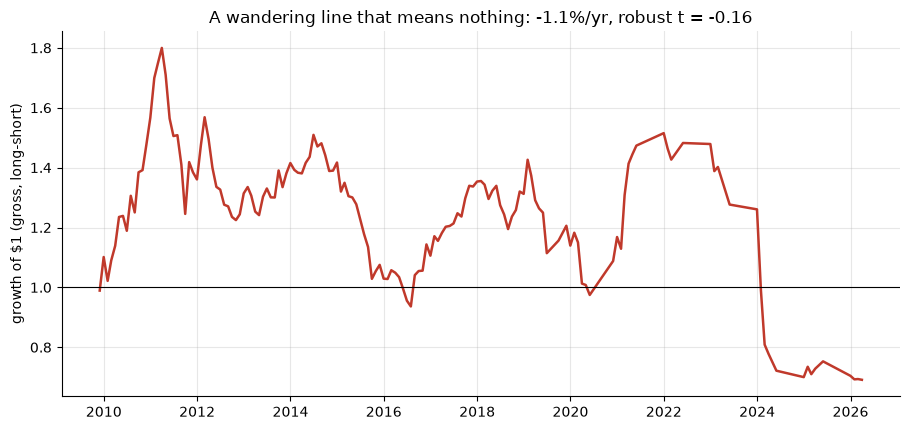

long-short: -1.1%/yr gross, Newey-West t = -0.16 (the bar is |2|)


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='rem', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ann, tnw = s['ann_pct'], s['t_nw']
    cum = (1+ls['ls']).cumprod()
else:
    ann, tnw = R['ls_ann'], R['ls_t_nw']
    cum = None
fig, ax = plt.subplots(figsize=(9.2, 4.4))
if cum is not None:
    ax.plot(cum.index, cum.values, color=RED, lw=1.8)
    ax.axhline(1.0, c='k', lw=.8)
    ax.set_ylabel('growth of $1 (gross, long-short)')
    ax.set_title(f'A wandering line that means nothing: {ann:+.1f}%/yr, robust t = {tnw:+.2f}')
else:
    ax.text(.5,.5,'run with cache for the equity curve',ha='center'); ax.set_axis_off()
plt.tight_layout(); plt.show()
print(f'long-short: {ann:+.1f}%/yr gross, Newey-West t = {tnw:+.2f} (the bar is |2|)')

It wanders around \$1 and ends slightly **below** it — **-1.1%/yr** gross, robust *t* = **-0.16**. That is a zero. Not 'a small edge': a coin-flip whose cumulative line drifts because monthly returns are noisy, not because anything is being predicted.

**The tell that it's noise:** a real signal keeps its sign when you change an arbitrary knob. This one doesn't. Here's the same long-short computed two ways — holding a signal up to ~6.5 months (staleness 200) vs ~4 months (staleness 120) — and split into an early and a late half.

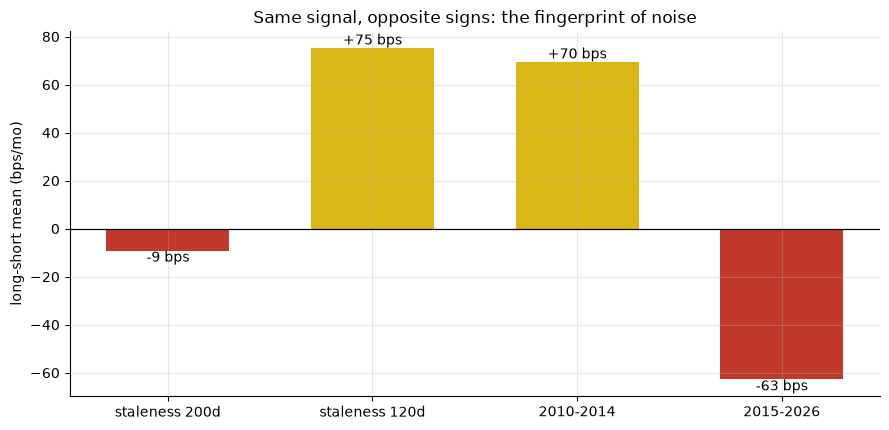

the long-short mean flips sign across the staleness knob and across eras — not an edge


In [3]:
labels = ['staleness 200d','staleness 120d','2010-2014','2015-2026']
if HAVE_REAL:
    ls200 = st.calendar_ls(PX, EV, signal_col='rem', staleness_days=200)
    ls120 = st.calendar_ls(PX, EV, signal_col='rem', staleness_days=120)
    b200 = st.calendar_ls_stats(ls200)['mean_bps']; b120 = st.calendar_ls_stats(ls120)['mean_bps']
    e = ls200[ls200.index < '2015-01-01']['ls'].to_numpy(); l = ls200[ls200.index >= '2015-01-01']['ls'].to_numpy()
    vals = [b200, b120, e.mean()*1e4, l.mean()*1e4]
else:
    vals = [R['ls_mean_bps'], R['ls120_mean_bps'], R['era_early_bps'], R['era_late_bps']]
cols = [RED if v < 0 else AMBER for v in vals]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(labels, vals, color=cols, width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:+.0f} bps',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.9); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Same signal, opposite signs: the fingerprint of noise')
plt.tight_layout(); plt.show()
print('the long-short mean flips sign across the staleness knob and across eras — not an edge')

Look at that: **-9** vs **+75** bps just from the staleness knob, and **+70** vs **-63** across the 2015 split. A live edge is stubborn about its sign; this one changes its mind every time we change an arbitrary setting. That's the signature of no signal at all.

**And the ladder?** If REM sorted returns, the middle third should sit between the top and bottom. It doesn't.

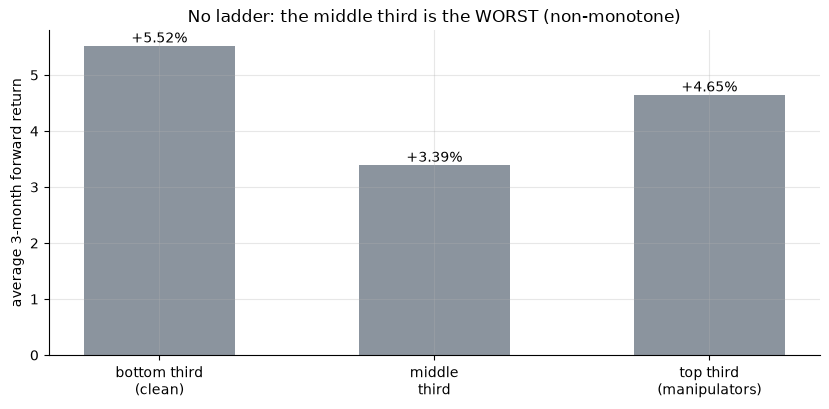

3-month forward return by REM third (low->high): ['+5.52%', '+3.39%', '+4.65%']


In [4]:
if HAVE_REAL:
    fr = st.event_drift_frame(PX, EV, horizon=63)
    mono = st.bucket_means(fr, 3)*100
else:
    mono = np.array(R['mono63'])
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(['bottom third\n(clean)','middle\nthird','top third\n(manipulators)'], mono,
       color=[GREY, GREY, GREY], width=.55)
for i,v in enumerate(mono): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('average 3-month forward return')
ax.set_title('No ladder: the middle third is the WORST (non-monotone)')
plt.tight_layout(); plt.show()
print('3-month forward return by REM third (low->high):', [f'{v:+.2f}%' for v in mono])

No staircase — the *middle* third is the worst, which no real sort produces. Whether we look at the calendar long-short, the sign-instability, or this event-drift ladder, the three agree: **there is no return sort in the REM proxy on this tape.**

**One more, the mechanism:** if the overproduction story were operating here, high-REM firms' gross margins should *give back* next quarter. Do they?

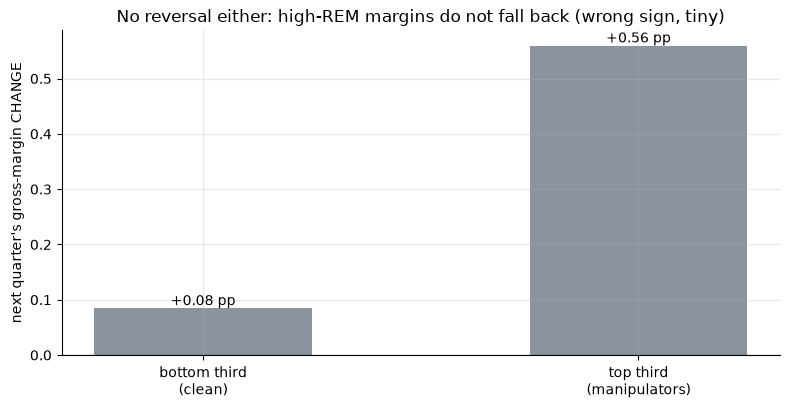

forward gross-margin change: top third +0.56 pp vs bottom +0.08 pp — no give-back


In [5]:
if HAVE_REAL:
    q = st.leads_operating(EV)
    top, bot = q['top_dgm']*100, q['bot_dgm']*100
else:
    top, bot = R['op_top_dgm'], R['op_bot_dgm']
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(['bottom third\n(clean)','top third\n(manipulators)'], [bot, top], color=[GREY, GREY], width=.5)
for i,v in enumerate([bot, top]): ax.annotate(f'{v:+.2f} pp',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel("next quarter's gross-margin CHANGE")
ax.set_title('No reversal either: high-REM margins do not fall back (wrong sign, tiny)')
plt.tight_layout(); plt.show()
print(f'forward gross-margin change: top third {top:+.2f} pp vs bottom {bot:+.2f} pp — no give-back')

The manipulator third's gross margin does **not** fall back next quarter — if anything it edges *up*, the opposite of the reversal the story predicts, and by a statistically negligible amount. On this small, industry-pooled panel the operating mechanism is not observable either. (That's an honest *non-detection*, not a claim that Roychowdhury's carefully-built industry-year original was wrong.)

## 5 · The verdict

- **Signal (returns) — None.** Robust *t* = -0.16, and the sign flips across the staleness knob and the 2015 split. The event drift is flat and non-monotone. No stable sign, no significance.
- **Tradability — Mirage.** You can't get paid for a coin-flip; it fails before costs.
- **Operating reversal — Not detected.** High-REM firms show no next-quarter gross-margin give-back on this panel (wrong-signed, insignificant).

> The honest one-liner: *real earnings management is a genuine thing companies do, and a genuinely useless thing to rank stocks on — here, twice over.*

## 6 · Going further 🚪

- **Where an edge might still hide.** Not in a pooled residual across mixed industries, but in Roychowdhury's original **industry-year** estimation with hundreds of names per bin, or **conditioned on firms that just barely beat** consensus (the population REM was designed to flag). A cleaner residual on a wider panel is the honest next step — this thin, pooled version can't see it.
- **The coverage caveat is real.** Quarterly Q4 tags are missing, several names never report R&D, and only 32 of 44 names clear the usable bar — the cross-section averages ≈17. A deeper panel might sharpen the test, though the flat event drift makes a large hidden return edge unlikely.
- **Sibling studies:** [574-penny-beat](../../574-penny-beat/) (the *just-beat* discontinuity REM is one mechanism for), [229-beneish-m-score](../../229-beneish-m-score/) and [855-accrual-quality](../../855-accrual-quality/) (the *accrual* channel REM avoids), and [525-r-and-d-intensity](../../525-r-and-d-intensity/) (the R&D *level*, not the residual). See [docs/references.md](docs/references.md) for the exact dedup.

*Think the alpha is in the industry-year residual or the just-beat subsample? Build it, show a certifiable net spread on the size you'd actually run — then we'll talk.*